# 决策树剪枝：Pima 糖尿病数据

作业要求：训练完整的 C4.5 风格决策树 → 诊断过拟合 → 预剪枝 → 后剪枝（代价复杂度剪枝）→ 三者对比 → 结论。

说明：
- sklearn 的 `DecisionTreeClassifier` 实现的是 CART（二叉分裂）。这里用 `criterion='entropy'`（按信息增益分裂）来近似 C4.5；C4.5 原本用信息增益率，并自带悲观错误剪枝，这两点 sklearn 没有。
- 作业要求的"代价复杂度剪枝"本身就是 CART 的后剪枝方法，sklearn 用 `ccp_alpha` 参数实现。
- 所有需要选择的东西（剪枝参数）都只在训练集上用交叉验证选，测试集只用来报告最终结果。

In [1]:
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if os.path.exists('/content'):
    os.system('apt-get -qq install -y fonts-noto-cjk > /dev/null')
    font_path = glob.glob('/usr/share/fonts/**/NotoSansCJK*-Regular.ttc', recursive=True)[0]
    fm.fontManager.addfont(font_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
else:
    plt.rcParams['font.family'] = ['PingFang SC', 'Heiti SC', 'Arial Unicode MS', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

## 0. 读数据

数据来自 Kaggle 的 `diabetes.csv`（768 行，8 个特征 + 标签 Outcome）。本地没有时自动从公开镜像下载，下载后核对行数和患病人数。

In [2]:
import time
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')

DATA_DIR = os.environ.get('PIMA_DATA_DIR', 'data')
os.makedirs(DATA_DIR, exist_ok=True)
path = f'{DATA_DIR}/diabetes.csv'
if not os.path.exists(path):
    import urllib.request
    urllib.request.urlretrieve('https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv', path)

df = pd.read_csv(path)
assert df.shape == (768, 9) and df['Outcome'].sum() == 268, '数据和 Kaggle 原版对不上'
print(df.shape, '患病', df['Outcome'].sum(), f"（{df['Outcome'].mean():.1%}）")
df.head()

(768, 9) 患病 268 （34.9%）


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. 数据检查：那些不可能的 0

血糖、血压、皮褶厚度、胰岛素、BMI 为 0 在生理上不可能，是缺失值被记成了 0。怀孕次数为 0 是正常的，不算缺失。

In [3]:
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
missing = pd.DataFrame({'取值为 0 的人数': (df[zero_cols] == 0).sum(),
                        '占比': (df[zero_cols] == 0).mean().round(3)})
missing

,取值为 0 的人数,占比
Glucose,5,0.007
BloodPressure,35,0.046
SkinThickness,227,0.296
Insulin,374,0.487
BMI,11,0.014


处理方式：把这五列的 0 改成缺失值，再用**训练集的中位数**填补。填补放在 `Pipeline` 里，交叉验证时每一折只用该折的训练部分算中位数，避免测试数据的信息漏进训练。

不按"患病 / 未患病"分组填中位数：网上不少做法这样做，但填补时用到了标签，等于把答案提前告诉了模型。

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier

X = df.drop(columns='Outcome').copy()
y = df['Outcome'].values
X[zero_cols] = X[zero_cols].replace(0, np.nan)
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
print(f'训练集 {len(y_train)} 行（患病 {y_train.sum()}），测试集 {len(y_test)} 行（患病 {y_test.sum()}）')

def make_tree(**params):
    return Pipeline([('impute', SimpleImputer(strategy='median')),
                     ('tree', DecisionTreeClassifier(criterion='entropy', random_state=42, **params))])

训练集 537 行（患病 187），测试集 231 行（患病 81）


## 2. 原始模型：不加任何限制的完整树

一直分裂，直到每个叶子只剩一类样本。

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def evaluate(name, model):
    start = time.time()
    model.fit(X_train, y_train)
    fit_time = time.time() - start
    tree = model.named_steps['tree']
    p_test = model.predict_proba(X_test)[:, 1]
    pred_test = model.predict(X_test)
    return {'模型': name,
            '训练集准确率': accuracy_score(y_train, model.predict(X_train)),
            '测试集准确率': accuracy_score(y_test, pred_test),
            '精确率': precision_score(y_test, pred_test),
            '召回率': recall_score(y_test, pred_test),
            'F1': f1_score(y_test, pred_test),
            'AUC': roc_auc_score(y_test, p_test),
            '深度': tree.get_depth(),
            '叶子数': tree.get_n_leaves(),
            '节点数': tree.tree_.node_count,
            '训练耗时(秒)': fit_time}

full = make_tree()
row_full = evaluate('原始完整树', full)
pd.Series(row_full).to_frame('原始完整树')

,原始完整树
模型,原始完整树
训练集准确率,1.0
测试集准确率,0.718615
精确率,0.605263
召回率,0.567901
F1,0.585987
AUC,0.683951
深度,22
叶子数,95
节点数,189


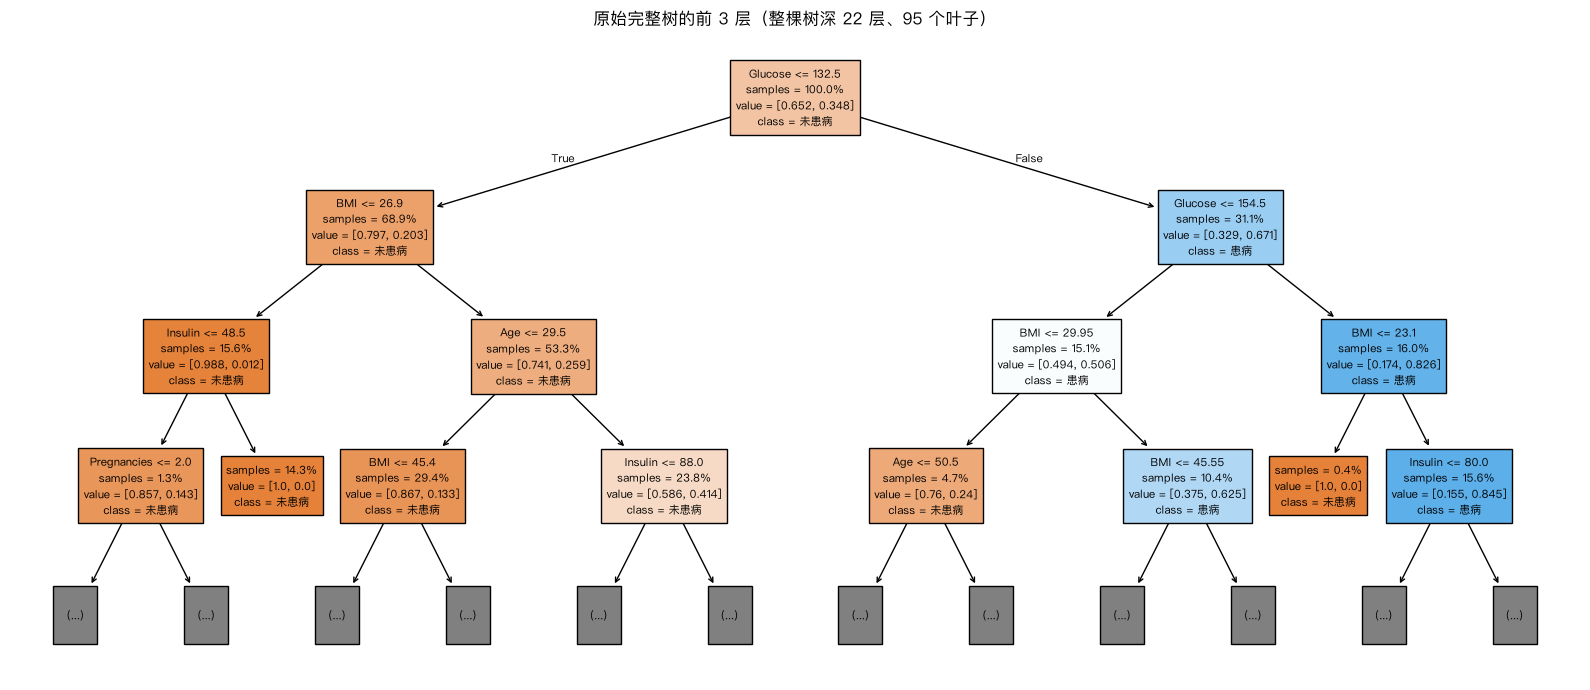

In [6]:
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(full.named_steps['tree'], max_depth=3, feature_names=feature_names,
          class_names=['未患病', '患病'], filled=True, impurity=False, proportion=True, fontsize=8, ax=ax)
ax.set_title(f"原始完整树的前 3 层（整棵树深 {row_full['深度']} 层、{row_full['叶子数']} 个叶子）")
plt.tight_layout()
plt.show()

## 3. 过拟合诊断

三种方法：
1. 训练集与测试集准确率之差；
2. 交叉验证：只在训练集上做 5 折 × 重复 5 次，看平均分和波动；
3. 学习曲线：训练样本逐渐增加时，训练分数和验证分数怎么变。

另外画一条"深度–准确率"曲线，直接看树越深是否越过拟合。

In [7]:
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
res = cross_validate(make_tree(), X_train, y_train, cv=cv, scoring='accuracy', return_train_score=True)
print(f"训练集准确率：{row_full['训练集准确率']:.3f}；测试集准确率：{row_full['测试集准确率']:.3f}；差距 {row_full['训练集准确率'] - row_full['测试集准确率']:.3f}")
print(f"交叉验证（25 次）：训练折 {res['train_score'].mean():.3f}，验证折 {res['test_score'].mean():.3f} ± {res['test_score'].std():.3f}")

训练集准确率：1.000；测试集准确率：0.719；差距 0.281
交叉验证（25 次）：训练折 1.000，验证折 0.706 ± 0.044


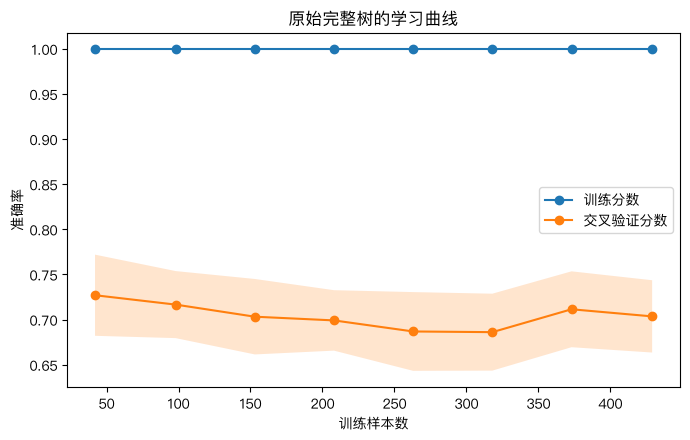

In [8]:
from sklearn.model_selection import learning_curve

sizes, tr, va = learning_curve(make_tree(), X_train, y_train, cv=cv, scoring='accuracy',
                               train_sizes=np.linspace(0.1, 1.0, 8), random_state=42)
fig, ax = plt.subplots(figsize=(7, 4.5))
for scores, label in [(tr, '训练分数'), (va, '交叉验证分数')]:
    ax.plot(sizes, scores.mean(1), marker='o', label=label)
    ax.fill_between(sizes, scores.mean(1) - scores.std(1), scores.mean(1) + scores.std(1), alpha=0.2)
ax.set_xlabel('训练样本数')
ax.set_ylabel('准确率')
ax.set_title('原始完整树的学习曲线')
ax.legend()
plt.tight_layout()
plt.show()

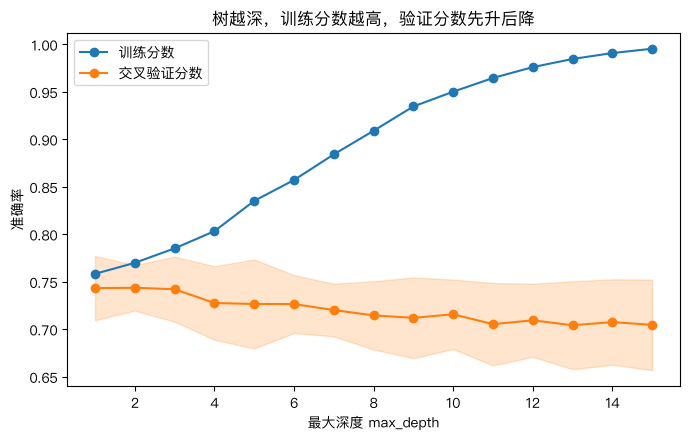

验证分数最高的深度： 2 （0.744）


In [9]:
from sklearn.model_selection import validation_curve

depths = list(range(1, 16))
tr_d, va_d = validation_curve(make_tree(), X_train, y_train, param_name='tree__max_depth',
                              param_range=depths, cv=cv, scoring='accuracy')
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(depths, tr_d.mean(1), marker='o', label='训练分数')
ax.plot(depths, va_d.mean(1), marker='o', label='交叉验证分数')
ax.fill_between(depths, va_d.mean(1) - va_d.std(1), va_d.mean(1) + va_d.std(1), alpha=0.2, color='C1')
ax.set_xlabel('最大深度 max_depth')
ax.set_ylabel('准确率')
ax.set_title('树越深，训练分数越高，验证分数先升后降')
ax.legend()
plt.tight_layout()
plt.show()
print('验证分数最高的深度：', depths[int(np.argmax(va_d.mean(1)))], f'（{va_d.mean(1).max():.3f}）')

## 4. 预剪枝：长树之前就设限制

在训练集上用同样的交叉验证做网格搜索，三个参数一起调：
- `max_depth`：最大深度
- `min_samples_leaf`：每个叶子至少多少个样本
- `min_samples_split`：节点至少多少个样本才允许再分

In [10]:
from sklearn.model_selection import GridSearchCV

grid = {'tree__max_depth': [2, 3, 4, 5, 6, 7, 8, 10, None],
        'tree__min_samples_leaf': [1, 2, 5, 10, 20, 40],
        'tree__min_samples_split': [2, 10, 20, 50]}
start = time.time()
gs = GridSearchCV(make_tree(), grid, cv=cv, scoring='accuracy', n_jobs=-1).fit(X_train, y_train)
print(f'搜索 {len(gs.cv_results_["params"])} 组参数，耗时 {time.time() - start:.1f} 秒')
print('最优参数：', {k.replace('tree__', ''): v for k, v in gs.best_params_.items()})
print(f'交叉验证准确率：{gs.best_score_:.3f}')

pre_params = {k.replace('tree__', ''): v for k, v in gs.best_params_.items()}
pre = make_tree(**pre_params)
row_pre = evaluate('预剪枝', pre)

搜索 216 组参数，耗时 53.4 秒
最优参数： {'max_depth': 5, 'min_samples_leaf': 10, 'min_samples_split': 50}
交叉验证准确率：0.754


In [11]:
top = pd.DataFrame(gs.cv_results_).sort_values('mean_test_score', ascending=False).head(10)
top = top[['param_tree__max_depth', 'param_tree__min_samples_leaf', 'param_tree__min_samples_split',
           'mean_test_score', 'std_test_score']]
top.columns = ['max_depth', 'min_samples_leaf', 'min_samples_split', '交叉验证准确率', '标准差']
top.round(3)

,max_depth,min_samples_leaf,min_samples_split,交叉验证准确率,标准差
87,5,10,50,0.754,0.036
38,3,10,20,0.752,0.034
36,3,10,2,0.752,0.034
37,3,10,10,0.752,0.034
183,10,10,50,0.751,0.041
207,None,10,50,0.751,0.041
135,7,10,50,0.751,0.041
159,8,10,50,0.751,0.041
111,6,10,50,0.750,0.038
39,3,10,50,0.750,0.034


## 5. 后剪枝：完整树 → 代价复杂度剪枝 → 交叉验证选 α

代价复杂度剪枝给每棵子树打分：**训练误差 + α × 叶子数**。α 越大，越偏好小树。
1. `cost_complexity_pruning_path` 在完整树上算出所有"关键 α"（每个 α 对应剪掉一个最不划算的分支后的树）；
2. 每个 α 都用交叉验证打分；
3. 选平均分最高的 α，用它在整个训练集上重新训练。

In [12]:
imputer = SimpleImputer(strategy='median').fit(X_train)
path = DecisionTreeClassifier(criterion='entropy', random_state=42).cost_complexity_pruning_path(
    imputer.transform(X_train), y_train)
alphas = path.ccp_alphas[:-1]   # 最后一个 α 会剪到只剩根节点
print(f'剪枝路径上共有 {len(alphas)} 个候选 α，范围 {alphas.min():.4f} ~ {alphas.max():.4f}')

start = time.time()
alpha_rows = []
for a in alphas:
    r = cross_validate(make_tree(ccp_alpha=a), X_train, y_train, cv=cv, scoring='accuracy', return_train_score=True)
    t = make_tree(ccp_alpha=a).fit(X_train, y_train).named_steps['tree']
    alpha_rows.append({'alpha': a, '训练分数': r['train_score'].mean(), '交叉验证分数': r['test_score'].mean(),
                       '标准差': r['test_score'].std(), '叶子数': t.get_n_leaves()})
alpha_df = pd.DataFrame(alpha_rows)
print(f'耗时 {time.time() - start:.1f} 秒')

best_alpha = alpha_df.loc[alpha_df['交叉验证分数'].idxmax(), 'alpha']
print(f'交叉验证最优 α = {best_alpha:.4f}，交叉验证准确率 {alpha_df["交叉验证分数"].max():.3f}')
post = make_tree(ccp_alpha=best_alpha)
row_post = evaluate('后剪枝', post)

剪枝路径上共有 46 个候选 α，范围 0.0000 ~ 0.0472


耗时 6.8 秒
交叉验证最优 α = 0.0397，交叉验证准确率 0.744


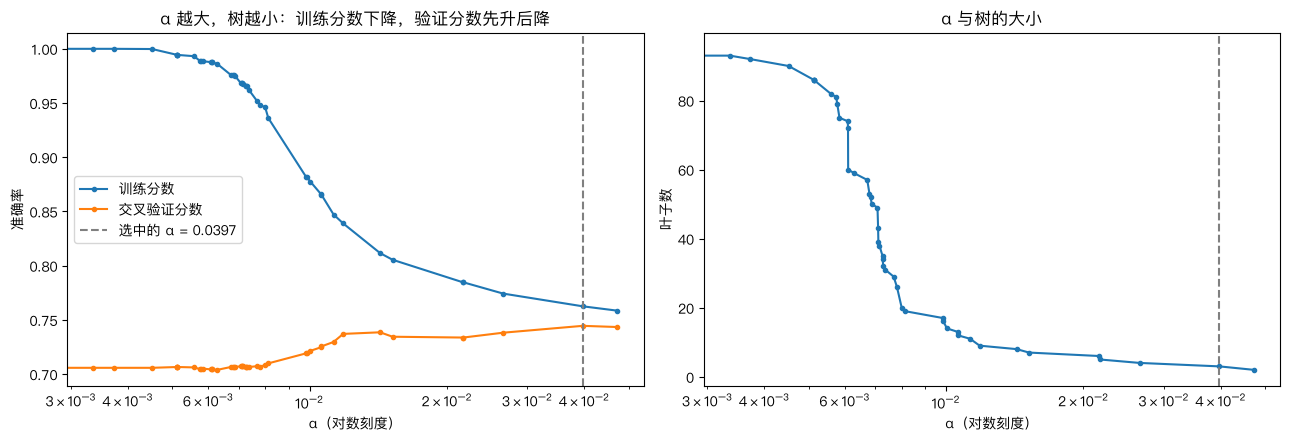

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ax = axes[0]
ax.plot(alpha_df['alpha'], alpha_df['训练分数'], marker='.', label='训练分数')
ax.plot(alpha_df['alpha'], alpha_df['交叉验证分数'], marker='.', label='交叉验证分数')
ax.axvline(best_alpha, color='gray', ls='--', label=f'选中的 α = {best_alpha:.4f}')
ax.set_xscale('log')
ax.set_xlabel('α（对数刻度）')
ax.set_ylabel('准确率')
ax.set_title('α 越大，树越小：训练分数下降，验证分数先升后降')
ax.legend()
ax = axes[1]
ax.plot(alpha_df['alpha'], alpha_df['叶子数'], marker='.')
ax.axvline(best_alpha, color='gray', ls='--')
ax.set_xscale('log')
ax.set_xlabel('α（对数刻度）')
ax.set_ylabel('叶子数')
ax.set_title('α 与树的大小')
plt.tight_layout()
plt.show()

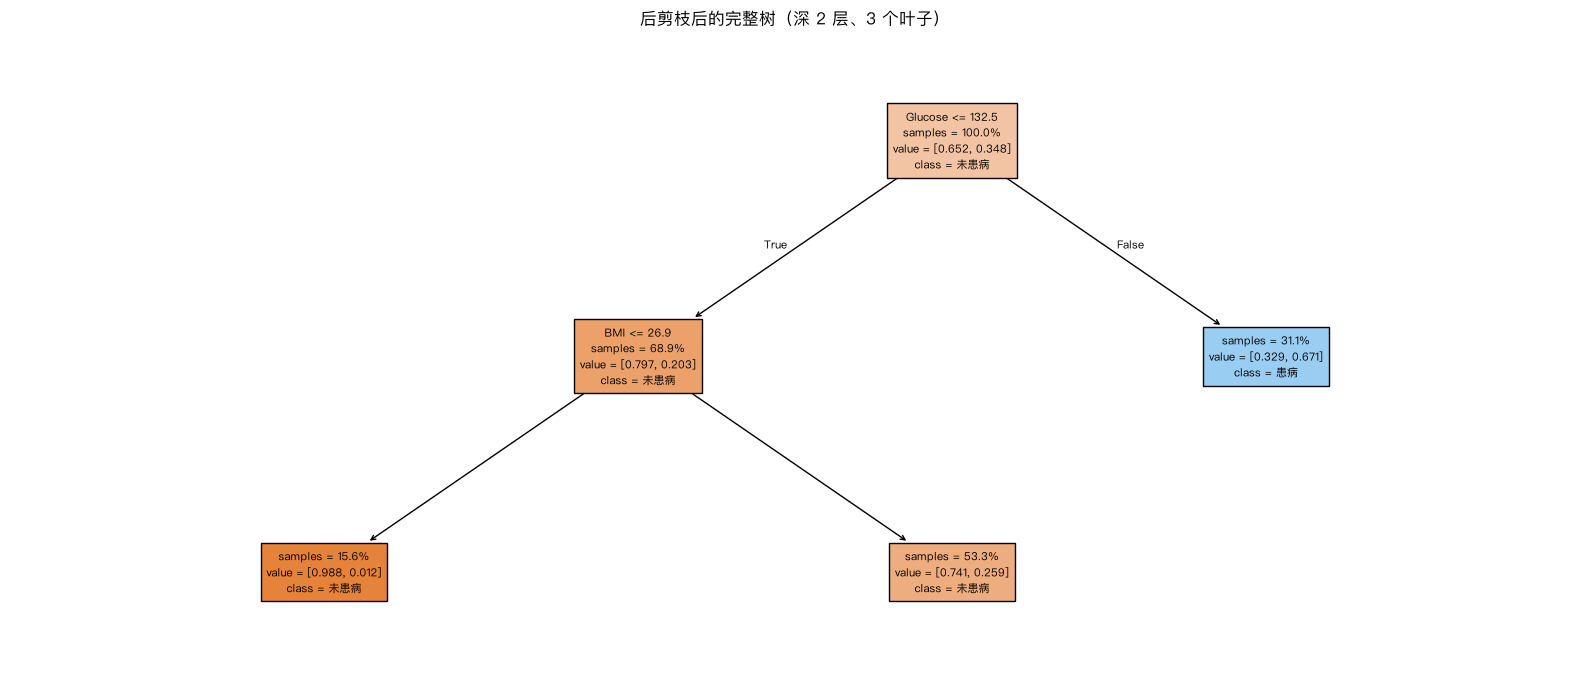

In [14]:
fig, ax = plt.subplots(figsize=(16, 7))
plot_tree(post.named_steps['tree'], feature_names=feature_names, class_names=['未患病', '患病'],
          filled=True, impurity=False, proportion=True, fontsize=8, ax=ax)
ax.set_title(f"后剪枝后的完整树（深 {row_post['深度']} 层、{row_post['叶子数']} 个叶子）")
plt.tight_layout()
plt.show()

## 6. 三个模型对比（测试集）

In [15]:
results = pd.DataFrame([row_full, row_pre, row_post]).set_index('模型')
results.round(3)

,训练集准确率,测试集准确率,精确率,召回率,F1,AUC,深度,叶子数,节点数,训练耗时(秒)
模型,,,,,,,,,,
原始完整树,1.000,0.719,0.605,0.568,0.586,0.684,22,95,189,0.045
预剪枝,0.814,0.753,0.688,0.543,0.607,0.788,5,14,27,0.010
后剪枝,0.758,0.693,0.568,0.519,0.542,0.726,2,3,5,0.005


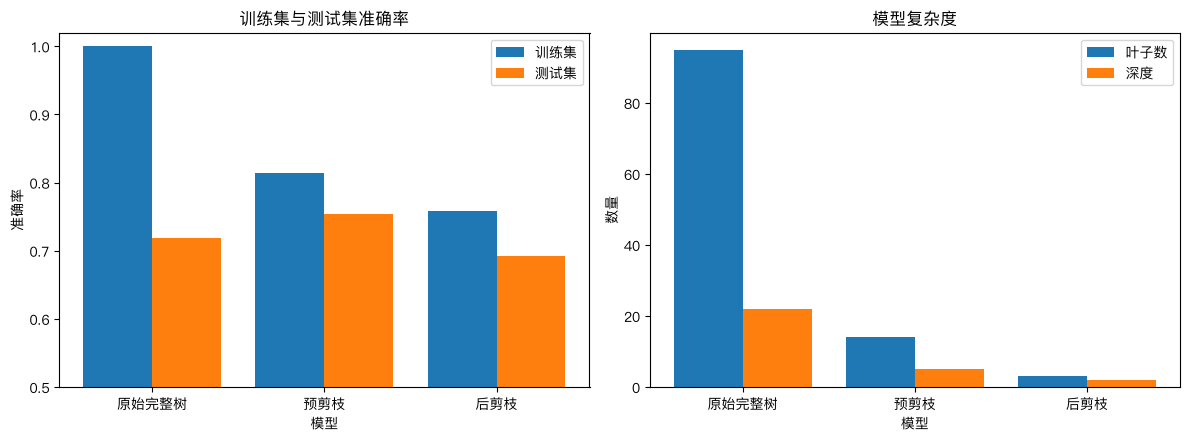

In [16]:
names = results.index.tolist()
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = np.arange(len(names))
axes[0].bar(x - 0.2, results['训练集准确率'], 0.4, label='训练集')
axes[0].bar(x + 0.2, results['测试集准确率'], 0.4, label='测试集')
axes[0].set_xticks(x)
axes[0].set_xticklabels(names)
axes[0].set_ylim(0.5, 1.02)
axes[0].set_xlabel('模型')
axes[0].set_ylabel('准确率')
axes[0].set_title('训练集与测试集准确率')
axes[0].legend()
axes[1].bar(x - 0.2, results['叶子数'], 0.4, label='叶子数')
axes[1].bar(x + 0.2, results['深度'], 0.4, label='深度')
axes[1].set_xticks(x)
axes[1].set_xticklabels(names)
axes[1].set_xlabel('模型')
axes[1].set_ylabel('数量')
axes[1].set_title('模型复杂度')
axes[1].legend()
plt.tight_layout()
plt.show()

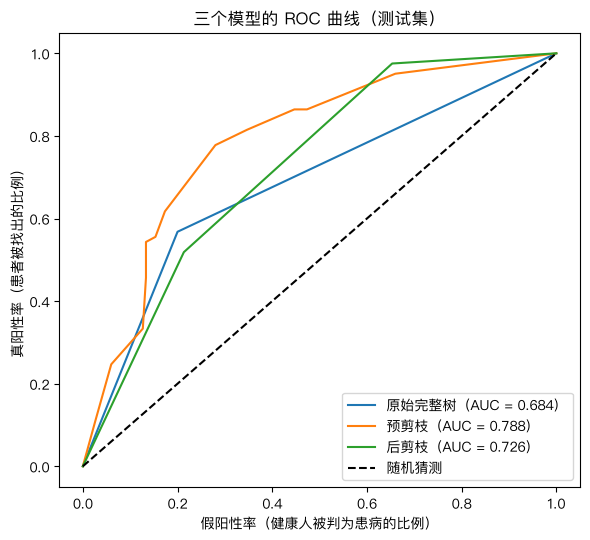

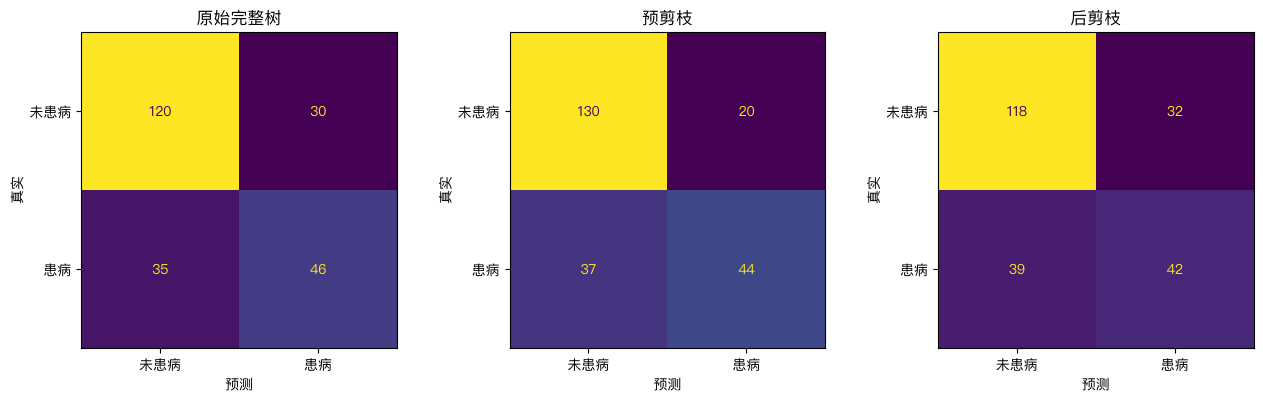

In [17]:
from sklearn.metrics import roc_curve, ConfusionMatrixDisplay

models = {'原始完整树': full, '预剪枝': pre, '后剪枝': post}
fig, ax = plt.subplots(figsize=(6, 5.5))
for name, m in models.items():
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:, 1])
    ax.plot(fpr, tpr, label=f"{name}（AUC = {results.loc[name, 'AUC']:.3f}）")
ax.plot([0, 1], [0, 1], 'k--', label='随机猜测')
ax.set_xlabel('假阳性率（健康人被判为患病的比例）')
ax.set_ylabel('真阳性率（患者被找出的比例）')
ax.set_title('三个模型的 ROC 曲线（测试集）')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, m) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, m.predict(X_test), display_labels=['未患病', '患病'],
                                            colorbar=False, ax=ax)
    ax.set_title(name)
    ax.set_xlabel('预测')
    ax.set_ylabel('真实')
plt.tight_layout()
plt.show()

## 7. 结果稳不稳：换 20 次划分重做

测试集只有 231 人，一次划分的结果受运气影响很大。这里把"划分 → 选参数 → 测试"整个流程重复 20 次，每次的剪枝参数都只在当次的训练集上重新选，看三个模型的测试准确率均值和波动。

In [18]:
from sklearn.model_selection import StratifiedKFold

def run_split(seed):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)
    inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    imp = SimpleImputer(strategy='median').fit(Xtr)
    a_path = DecisionTreeClassifier(criterion='entropy', random_state=42).cost_complexity_pruning_path(
        imp.transform(Xtr), ytr).ccp_alphas[:-1]
    fitted = {
        '原始完整树': make_tree().fit(Xtr, ytr),
        '预剪枝': GridSearchCV(make_tree(), grid, cv=inner, scoring='accuracy', n_jobs=-1).fit(Xtr, ytr).best_estimator_,
        '后剪枝': GridSearchCV(make_tree(), {'tree__ccp_alpha': a_path}, cv=inner, scoring='accuracy',
                            n_jobs=-1).fit(Xtr, ytr).best_estimator_,
    }
    out = {}
    for name, m in fitted.items():
        pred = m.predict(Xte)
        out[name] = {'准确率': accuracy_score(yte, pred), 'AUC': roc_auc_score(yte, m.predict_proba(Xte)[:, 1]),
                     '召回率': recall_score(yte, pred), '叶子数': m.named_steps['tree'].get_n_leaves()}
    return out

start = time.time()
rep = [run_split(s) for s in range(20)]
print(f'耗时 {time.time() - start:.0f} 秒')
metric = lambda key: pd.DataFrame({k: [r[k][key] for r in rep] for k in models})
acc, auc, rec, leaves = metric('准确率'), metric('AUC'), metric('召回率'), metric('叶子数')
summary = pd.DataFrame({'测试准确率均值': acc.mean(), '标准差': acc.std(), '最低': acc.min(), '最高': acc.max(),
                        'AUC 均值': auc.mean(), 'AUC 标准差': auc.std(), '召回率均值': rec.mean(),
                        '叶子数中位数': leaves.median()})
print('准确率均值（4 位小数）：', acc.mean().round(4).to_dict())
summary.round(3)

耗时 67 秒
准确率均值（4 位小数）： {'原始完整树': 0.718, '预剪枝': 0.7426, '后剪枝': 0.7426}


,测试准确率均值,标准差,最低,最高,AUC 均值,AUC 标准差,召回率均值,叶子数中位数
原始完整树,0.718,0.032,0.645,0.771,0.686,0.035,0.580,91.0
预剪枝,0.743,0.033,0.636,0.788,0.801,0.034,0.575,16.5
后剪枝,0.743,0.031,0.675,0.792,0.783,0.049,0.591,7.5


In [19]:
rows = []
for label, frame in [('准确率', acc), ('AUC', auc)]:
    for a, b in [('预剪枝', '原始完整树'), ('后剪枝', '原始完整树'), ('后剪枝', '预剪枝')]:
        d = frame[a] - frame[b]
        rows.append({'指标': label, '比较': f'{a} − {b}', '平均差': d.mean(),
                     '前者更高': f'{(d > 0).sum()} / 20', '相同': f'{(d == 0).sum()} / 20'})
pd.DataFrame(rows).set_index(['指标', '比较']).round(4)

平均差     前者更高      相同
指标  比较                                  
准确率 预剪枝 − 原始完整树  0.0247  15 / 20  3 / 20
    后剪枝 − 原始完整树  0.0247  17 / 20  1 / 20
    后剪枝 − 预剪枝    0.0000  11 / 20  2 / 20
AUC 预剪枝 − 原始完整树  0.1150  20 / 20  0 / 20
    后剪枝 − 原始完整树  0.0964  19 / 20  0 / 20
    后剪枝 − 预剪枝   -0.0185   7 / 20  0 / 20

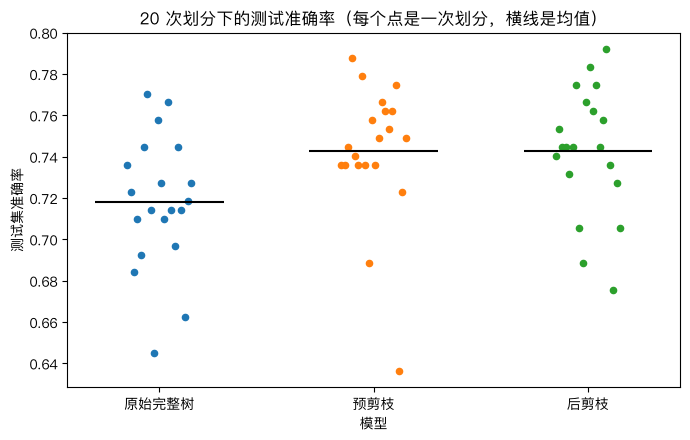

In [20]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for i, name in enumerate(models):
    v = acc[name].values
    ax.scatter(np.full(len(v), i) + np.linspace(-0.15, 0.15, len(v)), v, s=20)
    ax.hlines(v.mean(), i - 0.3, i + 0.3, color='black')
ax.set_xticks(range(len(models)))
ax.set_xticklabels(list(models))
ax.set_xlabel('模型')
ax.set_ylabel('测试集准确率')
ax.set_title('20 次划分下的测试准确率（每个点是一次划分，横线是均值）')
plt.tight_layout()
plt.show()

## 看完之后记下来（用你自己的话）

1. 原始树的训练和测试准确率差多少？学习曲线和深度曲线是怎么体现过拟合的？
2. 预剪枝选出了什么参数？和后剪枝选出的树相比，谁更小、谁更准？
3. 剪枝后的树还剩哪些特征？根节点是什么？这和你对糖尿病的常识一致吗？
4. 20 次划分里，剪枝是不是每次都比原始树好？三个模型的差距和单次划分的差距比，哪个更可信？
5. 如果让你给医院推荐一个模型，你选哪个？为什么？